In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [2]:
countries = ["ethiopia", "kenya", "sudan", "tanzania", "nigeria"]
frames = []
for c in countries:
    d = pd.read_csv(f"../data/{c}_clean.csv")
    d["country"] = c.capitalize()
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")
print(df.shape)
df.head()


(20540, 17)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year,country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,2015-01,2015.0,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,2015-01,2015.0,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,2015-01,2015.0,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,2015-01,2015.0,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,2015-01,2015.0,Ethiopia


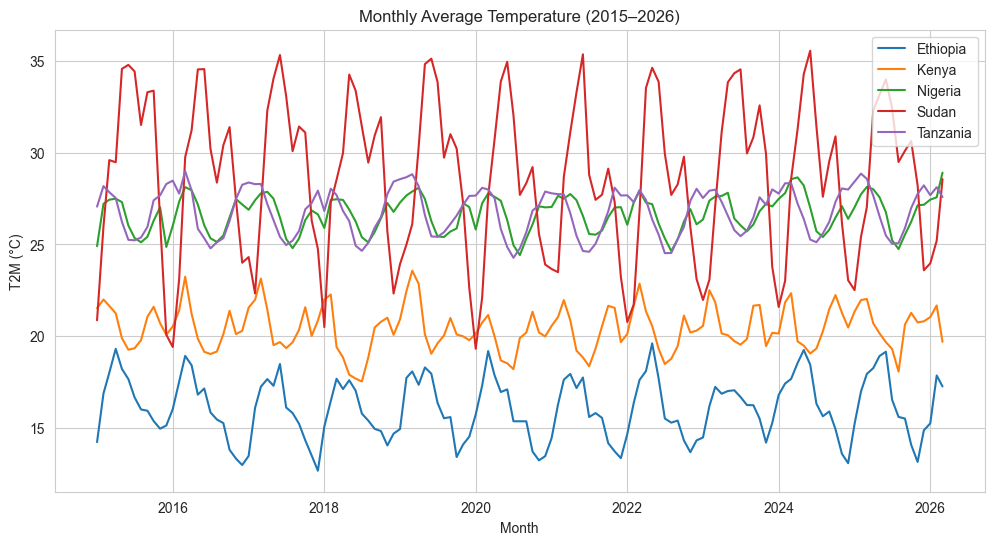

In [3]:
monthly = df.groupby(["country","Month"])["T2M"].mean().reset_index()
monthly["Month"] = monthly["Month"].dt.to_timestamp()

plt.figure(figsize=(12,6))
for c in monthly["country"].unique():
    sub = monthly[monthly["country"]==c]
    plt.plot(sub["Month"], sub["T2M"], label=c)
plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Month"); plt.ylabel("T2M (°C)")
plt.legend(); plt.show()


In [4]:
temp_summary = df.groupby("country")["T2M"].agg(["mean","median","std"]).round(2)
print(temp_summary)


           mean  median   std
country                      
Ethiopia  16.07   16.04  1.90
Kenya     20.43   20.36  1.44
Nigeria   26.66   26.82  1.12
Sudan     28.76   29.16  4.68
Tanzania  26.80   26.99  1.33


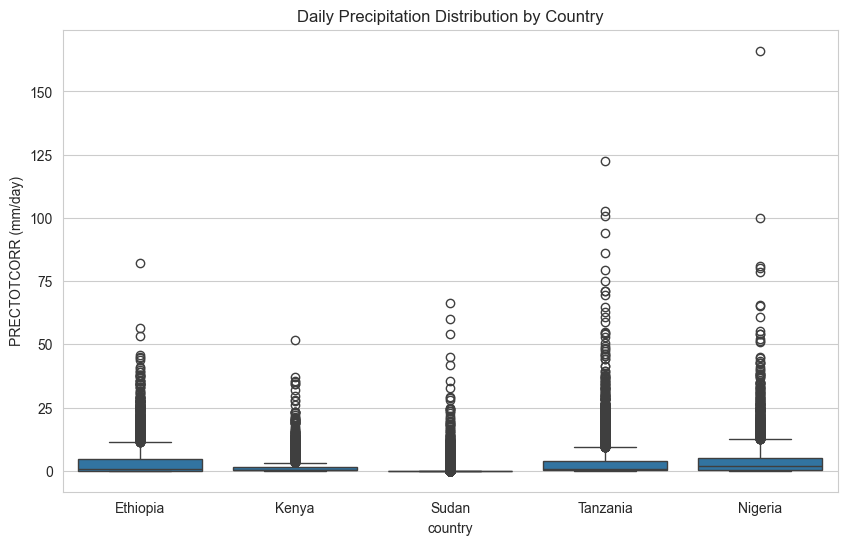

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="country", y="PRECTOTCORR")
plt.title("Daily Precipitation Distribution by Country")
plt.ylabel("PRECTOTCORR (mm/day)")
plt.show()


In [6]:
precip_summary = df.groupby("country")["PRECTOTCORR"].agg(["mean","median","std"]).round(2)
print(precip_summary)


          mean  median   std
country                     
Ethiopia  3.63    0.82  6.29
Kenya     1.47    0.38  3.18
Nigeria   4.21    1.84  7.27
Sudan     0.64    0.00  3.06
Tanzania  3.74    0.64  8.00


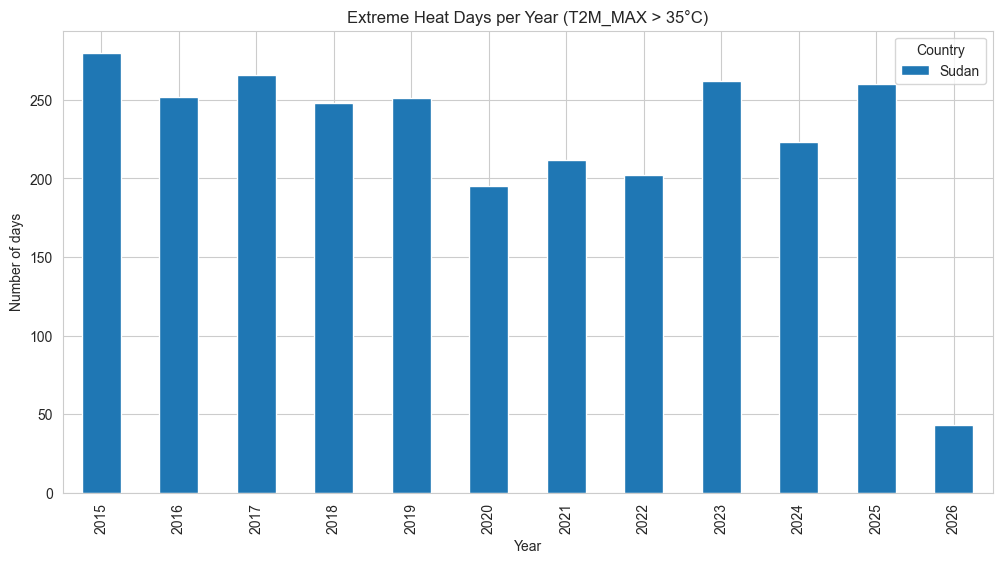

Date,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
country,,,,,,,,,,,,
Sudan,280,252,266,248,251,195,212,202,262,223,260,43


In [7]:
hot = df[df["T2M_MAX"] > 35].groupby(["country", df["Date"].dt.year]).size().unstack(fill_value=0)
hot.T.plot(kind="bar", figsize=(12,6))
plt.title("Extreme Heat Days per Year (T2M_MAX > 35°C)")
plt.ylabel("Number of days"); plt.xlabel("Year")
plt.legend(title="Country"); plt.show()
hot


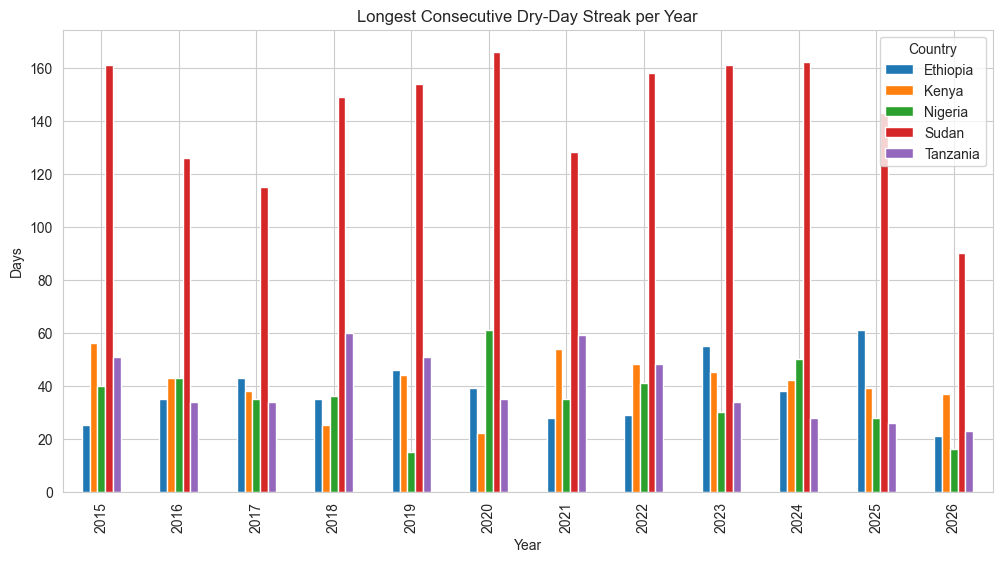

Date,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
country,,,,,,,,,,,,
Ethiopia,25,35,43,35,46,39,28,29,55,38,61,21
Kenya,56,43,38,25,44,22,54,48,45,42,39,37
Nigeria,40,43,35,36,15,61,35,41,30,50,28,16
Sudan,161,126,115,149,154,166,128,158,161,162,143,90
Tanzania,51,34,34,60,51,35,59,48,34,28,26,23


In [8]:
def max_dry_streak(series):
    dry = (series < 1).astype(int)
    streak = max_streak = 0
    for v in dry:
        streak = streak + 1 if v else 0
        max_streak = max(max_streak, streak)
    return max_streak

dry_table = df.groupby(["country", df["Date"].dt.year])["PRECTOTCORR"].apply(max_dry_streak).unstack(fill_value=0)
dry_table.T.plot(kind="bar", figsize=(12,6))
plt.title("Longest Consecutive Dry-Day Streak per Year")
plt.ylabel("Days"); plt.xlabel("Year")
plt.legend(title="Country"); plt.show()
dry_table


In [9]:
groups = [df[df["country"]==c]["T2M"].values for c in df["country"].unique()]
stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.2f}, p-value = {p:.5f}")
print("→ Significant differences between country temperatures" if p < 0.05 else "→ No significant difference")


Kruskal-Wallis H = 15392.99, p-value = 0.00000
→ Significant differences between country temperatures


In [10]:
rank = pd.DataFrame({
    "mean_temp": df.groupby("country")["T2M"].mean(),
    "max_temp":  df.groupby("country")["T2M_MAX"].max(),
    "rain_var":  df.groupby("country")["PRECTOTCORR"].std(),
    "hot_days":  df[df["T2M_MAX"]>35].groupby("country").size().reindex(df["country"].unique(), fill_value=0),
})
# normalize 0–1 and average → vulnerability score
rank_norm = (rank - rank.min()) / (rank.max() - rank.min())
rank["vulnerability_score"] = rank_norm.mean(axis=1).round(3)
rank = rank.sort_values("vulnerability_score", ascending=False)
print(rank)


          mean_temp  max_temp  rain_var  hot_days  vulnerability_score
country                                                               
Sudan     28.759007     45.96  3.057672      2694                0.750
Tanzania  26.802422     33.93  8.003947         0                0.511
Nigeria   26.656928     32.88  7.266742         0                0.454
Ethiopia  16.068500     30.93  6.289061         0                0.163
Kenya     20.427600     34.27  3.180228         0                0.148


## COP32 Insights

1. Sudan shows the highest baseline temperatures and most extreme heat days, supporting the heat-adaptation finance ask.  
2. Ethiopia shows rising mean T2M with low rainfall variability: chronic warming, not extremes, is the dominant signal.  
3. Kenya and Tanzania show the strongest precipitation variability, consistent with the 2020–2023 Horn of Africa drought + 2024 floods narrative.  
4. Nigeria's humidity + heat profile points to wet-bulb/ labor-productivity risk.  
5. Cross-country Kruskal–Wallis confirms climate exposure is statistically distinct → one-size-fits-all adaptation funding is inappropriate.